In [66]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import time
import zipfile
import os
from collections import Counter

np.random.seed(42)
plt.rcParams['figure.figsize'] = (10, 6)

In [67]:
X = pd.read_csv('kmeans_data/data.csv', header=None).values.astype(float)
y_true = pd.read_csv('kmeans_data/label.csv', header=None).values.flatten()

X = X / 255.0

K = len(np.unique(y_true))

print(f'X shape => {X.shape}')
print(f'y_true shape => {y_true.shape}')
print(f'K (classes) => {K}')
print(f'Class distribution => {Counter(y_true)}')

X shape => (10000, 784)
y_true shape => (10000,)
K (classes) => 10
Class distribution => Counter({1: 1135, 2: 1032, 7: 1028, 3: 1010, 9: 1009, 4: 982, 0: 980, 8: 974, 6: 958, 5: 892})


In [68]:
def euclidean_distance(a, b):
    return np.sqrt(np.sum((a - b) ** 2))


def cosine_distance(a, b):
    dot = np.dot(a, b)
    norm_a = np.linalg.norm(a)
    norm_b = np.linalg.norm(b)
    if norm_a == 0 or norm_b == 0:
        return 1.0          
    return 1.0 - dot / (norm_a * norm_b)


def jaccard_distance(a, b):
    numerator   = np.sum(np.minimum(a, b))
    denominator = np.sum(np.maximum(a, b))
    if denominator == 0:
        return 0.0
    return 1.0 - numerator / denominator


METRICS = {
    'Euclidean': euclidean_distance,
    'Cosine'   : cosine_distance,
    'Jaccard'  : jaccard_distance,
}

K-Means Implementation

In [69]:
def compute_sse(X, labels, centroids, dist_fn):
    sse = 0.0
    for i, x in enumerate(X):
        d = dist_fn(x, centroids[labels[i]])
        sse += d ** 2
    return sse


def assign_clusters(X, centroids, dist_fn):
    labels = np.empty(len(X), dtype=int)
    for i, x in enumerate(X):
        dists = [dist_fn(x, c) for c in centroids]
        labels[i] = int(np.argmin(dists))
    return labels


def update_centroids(X, labels, k):
    centroids = np.zeros((k, X.shape[1]))
    for j in range(k):
        mask = labels == j
        if mask.sum() > 0:
            centroids[j] = X[mask].mean(axis=0)
    return centroids


def kmeans(X, k, dist_fn, stop_no_change=True, stop_sse_increase=True, max_iter=500, random_state=42):
    rng = np.random.RandomState(random_state)
    init_idx = rng.choice(len(X), size=k, replace=False)
    centroids = X[init_idx].copy()

    sse_history = []
    stop_reason = 'max_iter'
    t0 = time.perf_counter()

    for iteration in range(1, max_iter + 1):
        labels = assign_clusters(X, centroids, dist_fn)
        sse = compute_sse(X, labels, centroids, dist_fn)
        sse_history.append(sse)

        new_centroids = update_centroids(X, labels, k)

        if stop_no_change and np.allclose(centroids, new_centroids):
            stop_reason = 'no_change'
            centroids = new_centroids
            break

        if stop_sse_increase and len(sse_history) >= 2 and sse > sse_history[-2]:
            stop_reason = 'sse_increase'
            centroids = new_centroids
            break

        centroids = new_centroids

    elapsed = time.perf_counter() - t0
    return labels, centroids, sse_history, iteration, stop_reason, elapsed

 Q1 SSEs of Euclidean, Cosine, and Jaccard K-Means

In [70]:
results_q1 = {}

for name, fn in METRICS.items():
    print(name + ' KMeans')
    labels, centroids, sse_hist, n_iter, reason, elapsed = kmeans(
        X, K, fn, stop_no_change=True, stop_sse_increase=False, max_iter=500
    )
    final_sse = sse_hist[-1]
    results_q1[name] = {
        'labels'   : labels,
        'centroids': centroids,
        'sse_hist' : sse_hist,
        'final_sse': final_sse,
        'n_iter'   : n_iter,
        'reason'   : reason,
        'elapsed'  : elapsed,
    }
    print(f'Final SSE={final_sse:.4f}  Iterations={n_iter}  Stop={reason}  Time={elapsed:.3f}s\n')

Euclidean KMeans
Final SSE=390846.1006  Iterations=33  Stop=no_change  Time=11.809s

Cosine KMeans
Final SSE=686.4356  Iterations=48  Stop=no_change  Time=26.268s

Jaccard KMeans
Final SSE=3660.3895  Iterations=59  Stop=no_change  Time=29.752s



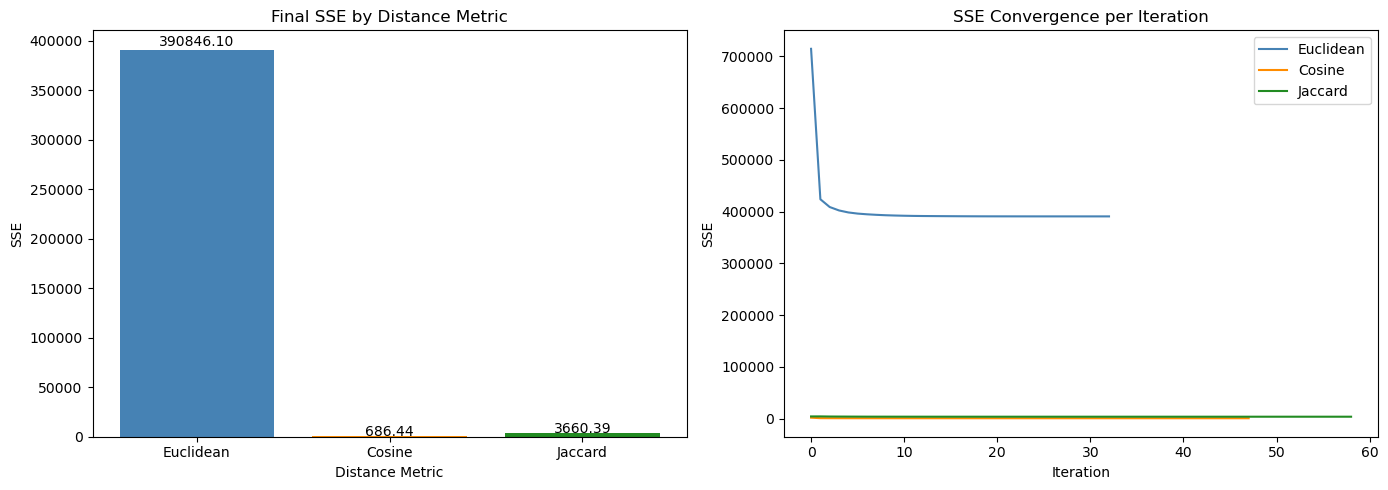


Q1 Summary:
  Euclidean   SSE = 390846.1006
  Cosine      SSE = 686.4356
  Jaccard     SSE = 3660.3895

=> Best metric by lowest SSE: Cosine


In [71]:

names  = list(results_q1.keys())
sses   = [results_q1[n]['final_sse'] for n in names]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = ['steelblue', 'darkorange', 'forestgreen']
axes[0].bar(names, sses, color=colors)
axes[0].set_title('Final SSE by Distance Metric')
axes[0].set_ylabel('SSE')
axes[0].set_xlabel('Distance Metric')
for i, v in enumerate(sses):
    axes[0].text(i, v * 1.01, f'{v:.2f}', ha='center', fontsize=10)

# --- SSE convergence curves ---
for name, c in zip(names, colors):
    axes[1].plot(results_q1[name]['sse_hist'], label=name, color=c)
axes[1].set_title('SSE Convergence per Iteration')
axes[1].set_xlabel('Iteration')
axes[1].set_ylabel('SSE')
axes[1].legend()

plt.tight_layout()
plt.savefig('q1_sse_comparison.png', dpi=150)
plt.show()

print('\nQ1 Summary:')
for name in names:
    print(f'  {name:10s}  SSE = {results_q1[name]["final_sse"]:.4f}')
best_q1 = min(names, key=lambda n: results_q1[n]['final_sse'])
print(f'\n=> Best metric by lowest SSE: {best_q1}')

Q2 — Compare Accuracies

In [72]:
def majority_vote_accuracy(true_labels, cluster_labels, k):
    label_map = {}
    for cluster_id in range(k):
        mask = cluster_labels == cluster_id
        if mask.sum() == 0:
            label_map[cluster_id] = -1
            continue
        votes = Counter(true_labels[mask])
        label_map[cluster_id] = votes.most_common(1)[0][0]

    predicted = np.array([label_map[c] for c in cluster_labels])
    accuracy  = np.mean(predicted == true_labels)
    return accuracy, label_map


print('Q2 — Accuracy Results')
print('-' * 45)
accs = {}
for name in names:
    acc, lmap = majority_vote_accuracy(y_true, results_q1[name]['labels'], K)
    accs[name] = acc
    print(f'{name:10s}  Accuracy = {acc:.4f}  ({acc*100:.2f}%)')
    print(f'           Cluster to Label map: {lmap}')

best_q2 = max(names, key=lambda n: accs[n])
print(f'\n=> Best metric by accuracy: {best_q2}')

Q2 — Accuracy Results
---------------------------------------------
Euclidean   Accuracy = 0.5851  (58.51%)
           Cluster to Label map: {0: 6, 1: 1, 2: 0, 3: 1, 4: 8, 5: 2, 6: 3, 7: 4, 8: 7, 9: 0}
Cosine      Accuracy = 0.6309  (63.09%)
           Cluster to Label map: {0: 6, 1: 1, 2: 3, 3: 9, 4: 8, 5: 2, 6: 1, 7: 4, 8: 7, 9: 0}
Jaccard     Accuracy = 0.6021  (60.21%)
           Cluster to Label map: {0: 6, 1: 1, 2: 0, 3: 1, 4: 7, 5: 2, 6: 3, 7: 4, 8: 9, 9: 8}

=> Best metric by accuracy: Cosine


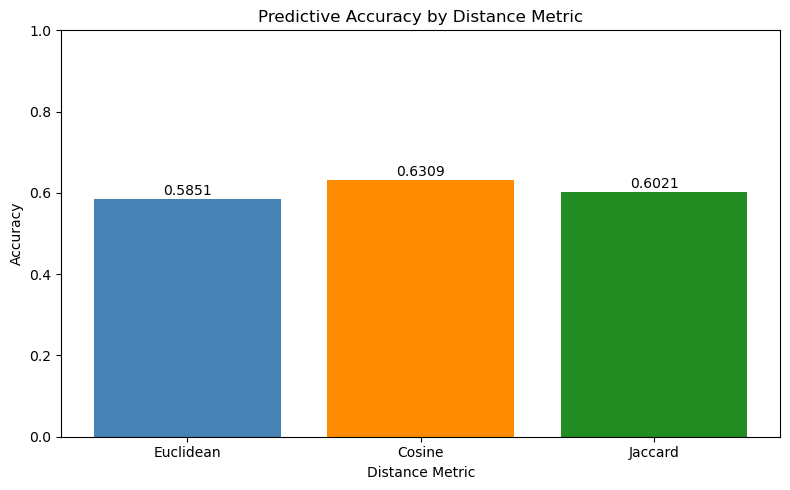

In [74]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(names, [accs[n] for n in names], color=colors)
ax.set_title('Predictive Accuracy by Distance Metric')
ax.set_ylabel('Accuracy')
ax.set_xlabel('Distance Metric')
ax.set_ylim(0, 1)
for i, n in enumerate(names):
    ax.text(i, accs[n] + 0.01, f'{accs[n]:.4f}', ha='center', fontsize=10)
plt.tight_layout()
plt.savefig('q2_accuracy_comparison.png', dpi=150)
plt.show()

Q3 Convergence: Iterations and Time


In [75]:
MAX_ITER_Q3 = 500
results_q3  = {}

print('Q3 Convergence Comparison (all stop criteria active, max_iter=500)')
print('-' * 65)

for name, fn in METRICS.items():
    labels, centroids, sse_hist, n_iter, reason, elapsed = kmeans(
        X, K, fn,
        stop_no_change=True, stop_sse_increase=True,
        max_iter=MAX_ITER_Q3
    )
    results_q3[name] = {
        'n_iter' : n_iter,
        'elapsed': elapsed,
        'reason' : reason,
        'sse_hist': sse_hist,
    }
    print(f'{name:10s}  Iterations={n_iter:4d}  Time={elapsed:.4f}s  Stop={reason}')

Q3 Convergence Comparison (all stop criteria active, max_iter=500)
-----------------------------------------------------------------
Euclidean   Iterations=  33  Time=11.7146s  Stop=no_change
Cosine      Iterations=  29  Time=15.6518s  Stop=sse_increase
Jaccard     Iterations=   2  Time=0.9985s  Stop=sse_increase


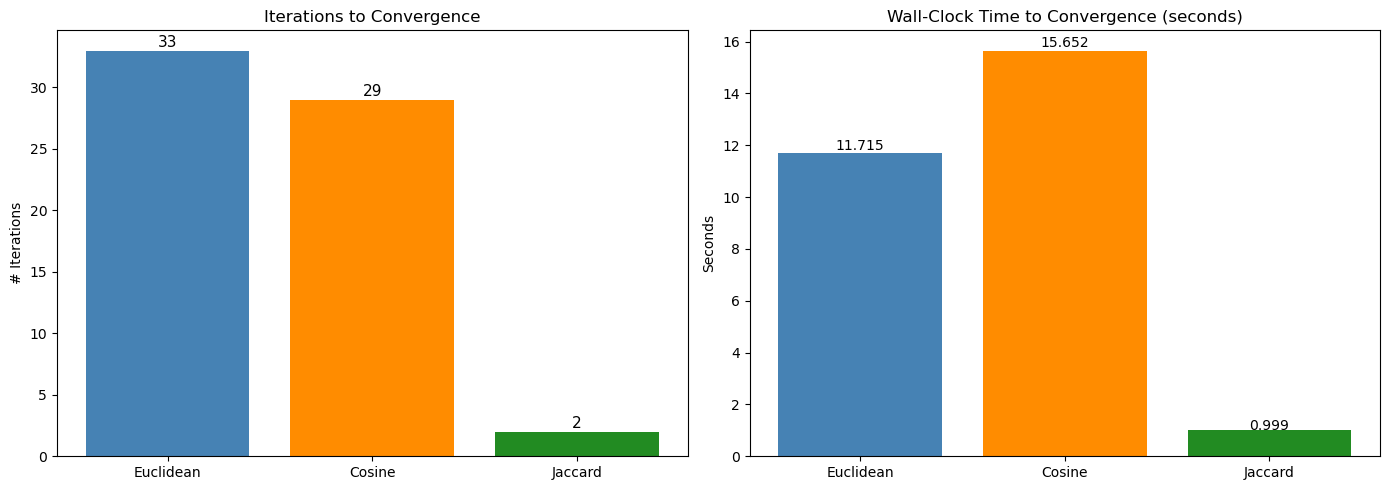

Most iterations : Euclidean (33 iters)
Most wall-clock : Cosine (15.6518s)


In [76]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

iters   = [results_q3[n]['n_iter']  for n in names]
times   = [results_q3[n]['elapsed'] for n in names]

axes[0].bar(names, iters, color=colors)
axes[0].set_title('Iterations to Convergence')
axes[0].set_ylabel('# Iterations')
for i, v in enumerate(iters):
    axes[0].text(i, v + 0.3, str(v), ha='center', fontsize=11)

axes[1].bar(names, times, color=colors)
axes[1].set_title('Wall-Clock Time to Convergence (seconds)')
axes[1].set_ylabel('Seconds')
for i, v in enumerate(times):
    axes[1].text(i, v * 1.01, f'{v:.3f}', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('q3_convergence.png', dpi=150)
plt.show()

slowest_iter = max(names, key=lambda n: results_q3[n]['n_iter'])
slowest_time = max(names, key=lambda n: results_q3[n]['elapsed'])
print(f'Most iterations : {slowest_iter} ({results_q3[slowest_iter]["n_iter"]} iters)')
print(f'Most wall-clock : {slowest_time} ({results_q3[slowest_time]["elapsed"]:.4f}s)')

Q4 SSE Comparison Under Three Separate Termination Conditions

In [77]:
STOP_CONDITIONS = [
    # (label,             no_change, sse_increase, max_iter)
    ('No Change',         True,      False,        500),
    ('SSE Increase',      False,     True,         500),
    ('Max Iter (100)',    False,     False,        100),
]

results_q4 = {cond_label: {} for cond_label, *_ in STOP_CONDITIONS}

for cond_label, nc, si, mi in STOP_CONDITIONS:
    print(f'\n--- Stop condition: "{cond_label}" ---')
    for name, fn in METRICS.items():
        labels, centroids, sse_hist, n_iter, reason, elapsed = kmeans(
            X, K, fn,
            stop_no_change=nc, stop_sse_increase=si, max_iter=mi
        )
        results_q4[cond_label][name] = sse_hist[-1]
        print(f'  {name:10s}  SSE={sse_hist[-1]:.4f}  Iters={n_iter}  Stop={reason}')


--- Stop condition: "No Change" ---
  Euclidean   SSE=390846.1006  Iters=33  Stop=no_change
  Cosine      SSE=686.4356  Iters=48  Stop=no_change
  Jaccard     SSE=3660.3895  Iters=59  Stop=no_change

--- Stop condition: "SSE Increase" ---
  Euclidean   SSE=390846.1006  Iters=500  Stop=max_iter
  Cosine      SSE=686.2293  Iters=29  Stop=sse_increase
  Jaccard     SSE=4239.9465  Iters=2  Stop=sse_increase

--- Stop condition: "Max Iter (100)" ---
  Euclidean   SSE=390846.1006  Iters=100  Stop=max_iter
  Cosine      SSE=686.4356  Iters=100  Stop=max_iter
  Jaccard     SSE=3660.3895  Iters=100  Stop=max_iter


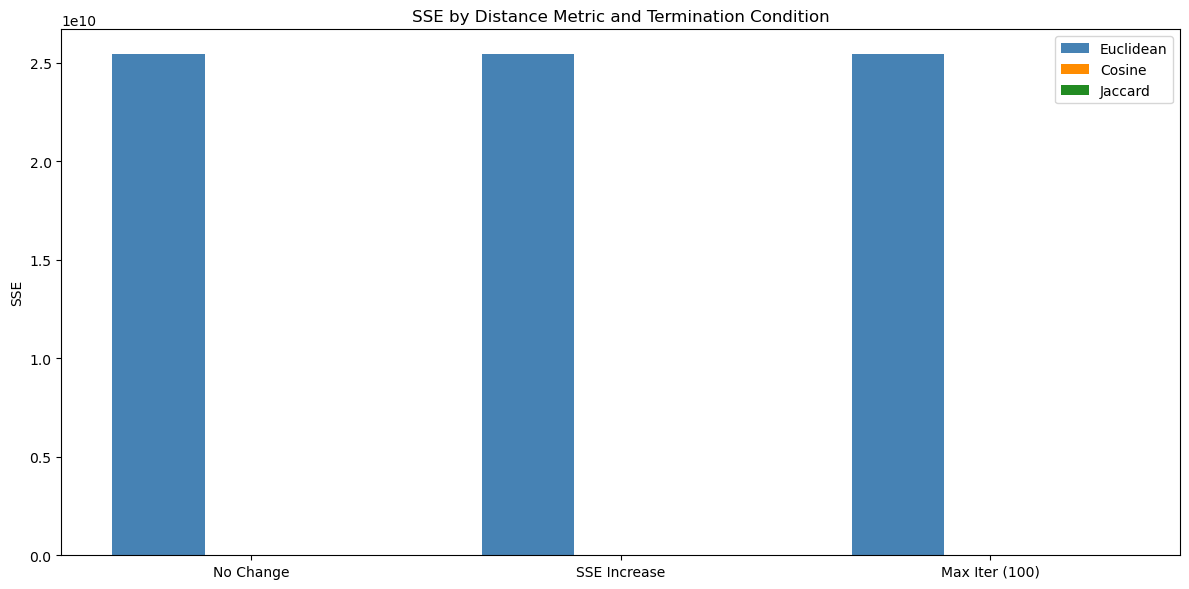


Q4 SSE Table:
                   Euclidean      Cosine      Jaccard
No Change       2.541477e+10  686.435573  3660.389494
SSE Increase    2.541477e+10  686.229294  4239.946465
Max Iter (100)  2.541477e+10  686.435573  3660.389494


In [12]:
cond_labels = [c[0] for c in STOP_CONDITIONS]
x_pos = np.arange(len(cond_labels))
width = 0.25

fig, ax = plt.subplots(figsize=(12, 6))

for i, (name, color) in enumerate(zip(names, colors)):
    sse_vals = [results_q4[cl][name] for cl in cond_labels]
    ax.bar(x_pos + i * width, sse_vals, width, label=name, color=color)

ax.set_title('SSE by Distance Metric and Termination Condition')
ax.set_ylabel('SSE')
ax.set_xticks(x_pos + width)
ax.set_xticklabels(cond_labels)
ax.legend()
plt.tight_layout()
plt.savefig('q4_sse_termination.png', dpi=150)
plt.show()

print('\nQ4 SSE Table:')
df_q4 = pd.DataFrame(results_q4).T
print(df_q4.to_string())